<a href="https://colab.research.google.com/github/Tamaki-Baba/data-Econometrics/blob/main/%E3%83%86%E3%82%99%E3%83%BC%E3%82%BF%E3%81%A8%E8%A8%88%E9%87%8F%E7%B5%8C%E6%B8%88%E5%AD%A6%E6%9C%80%E7%B5%82%E8%AA%B2%E9%A1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 概要

本課題では、これまでに学習した確率論およびベイズ推論の手法を統合し、CSVデータを入力として確率的推定と可視化を行うデータ分析アプリケーションを作成した。

本アプリケーションは、CSVファイルを読み込むことで、データの内容に応じた確率計算・ベイズ推定・MCMCによる推論を実行し、その結果をグラフとして出力する構成となっている。

### 特徴

- 同時確率・条件付き確率の考え方を基礎として、属性情報から事象が起こる確率を数理的に算出している
- ベイズの定理を用いることで、観測データに基づいた確率の更新を行っている
- 確率を1つの値としてではなく分布として推定するために、MCMC法を用いて事後分布を求めている
- 推定結果はヒストグラムや散布図として可視化し、数値だけでは分かりにくい傾向や不確実性を確認できる

### 意義

CSVファイルさえ用意すれば、特定の分野に限定されることなく、確率モデルに基づいた分析を実行できる。

また、実際のデータを使って、確率の計算から結果のグラフ表示までを一つの流れとして実装することで、確率やベイズ推論がデータ分析の中でどのように使われるのかを理解することを目的としている。

In [ ]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 60.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=1a5661e3063a2c2f4f6a8d26037477e67b353ec81d3b8385be15f4a5c7f53fc3
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


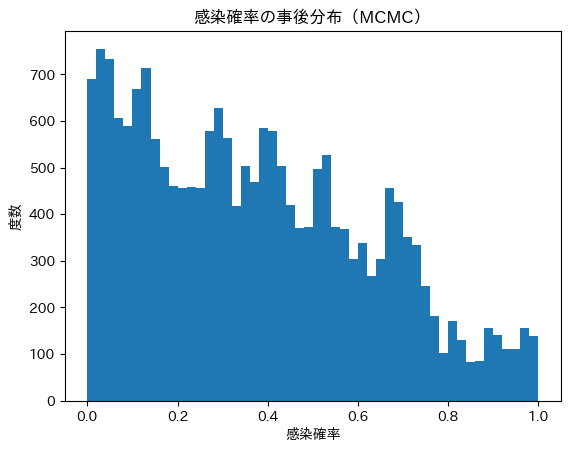

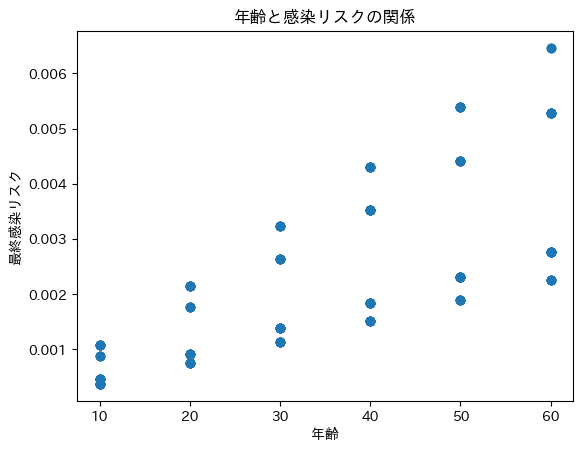

データ件数: 200
事前感染確率: 0.135
検査後感染確率: 0.7375
地域補正係数: 0.1386
最終感染リスク平均: 0.002334
95%信用区間: 0.014205 0.921429


In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import japanize_matplotlib

# データ読み込み

df = pd.read_csv("data.csv")

# 事前確率（有病率）

prior = df["infected"].mean()

# 3. 検査結果によるベイズ更新

sensitivity = 0.9
specificity = 0.95

posterior_test = (sensitivity * prior) / (
    sensitivity * prior + (1 - specificity) * (1 - prior)
)

# ナイーブベイズ（症状統合）

symptom_cols = ["fever", "cough"]

def nb_prob(row, df, label):
    subset = df[df["infected"] == label]
    prob = 1
    for col in symptom_cols:
        prob *= (subset[col].sum() + 1) / (len(subset) + 2)
    return prob

nb_probs = []
for _, row in df.iterrows():
    p_inf = nb_prob(row, df, 1)
    p_hea = nb_prob(row, df, 0)
    nb_probs.append(p_inf / (p_inf + p_hea))

df["symptom_prob"] = nb_probs

# 属性補正（簡易ベイジアンネットワーク）

df["attr_weight"] = (
    df["female"].map({1: 0.55, 0: 0.45}) *
    df["vaccinated"].map({1: 0.3, 0: 0.7}) *
    df["age"].map({
        10: 0.05,
        20: 0.1,
        30: 0.15,
        40: 0.2,
        50: 0.25,
        60: 0.3
    })
)

# 少数データ補正（ベイズ推定）

alpha, beta = 1, 1
D = df["infected"].sum()
P = len(df)

regional_adjustment = (alpha + D) / (alpha + beta + P)

# 総合感染リスク算出

df["final_risk"] = (
    posterior_test *
    df["symptom_prob"] *
    df["attr_weight"] *
    regional_adjustment
)

# MCMCによる不確実性評価

theta = df["final_risk"].mean()
samples = []

for _ in range(20000):
    proposal = theta + np.random.normal(0, 0.01)
    if 0 <= proposal <= 1:
        theta = proposal
    samples.append(theta)

samples = np.array(samples)

# グラフ表示

plt.figure()
plt.hist(samples, bins=50)
plt.xlabel("感染確率")
plt.ylabel("度数")
plt.title("感染確率の事後分布（MCMC）")
plt.show()

plt.figure()
plt.scatter(df["age"], df["final_risk"])
plt.xlabel("年齢")
plt.ylabel("最終感染リスク")
plt.title("年齢と感染リスクの関係")
plt.show()

# 結果

print("データ件数:", len(df))
print("事前感染確率:", round(prior, 4))
print("検査後感染確率:", round(posterior_test, 4))
print("地域補正係数:", round(regional_adjustment, 4))
print("最終感染リスク平均:", round(df['final_risk'].mean(), 6))
print("95%信用区間:",
      round(np.percentile(samples, 2.5), 6),
      round(np.percentile(samples, 97.5), 6))

